In [1]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

d:\Collage\AAST\9-AAST 8\Prof AI 3\Emotion Detection in Tweets\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("dair-ai/emotion")

test_data = dataset["test"]

In [3]:
tokenizer = AutoTokenizer.from_pretrained("./model_full")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def evaluate(model, dataset):
    model.to(device)
    model.eval()

    preds = []
    labels = []

    for item in dataset:
        inputs = tokenizer(
            item["text"],
            return_tensors="pt",
            truncation=True,
            padding=True
        ).to(device)

        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

        preds.append(pred)
        labels.append(item["label"])

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return acc, f1

In [5]:
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=6
)

baseline_acc, baseline_f1 = evaluate(baseline_model, test_data)

print("Baseline:", baseline_acc, baseline_f1)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Baseline: 0.1125 0.025492025194832922


In [10]:
full_model = AutoModelForSequenceClassification.from_pretrained("./model_full")

full_acc, full_f1 = evaluate(full_model, test_data)

print("Full:", full_acc, full_f1)

Full: 0.9305 0.9289825400298672


In [7]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    "albert-base-v2",
    num_labels=6
)

lora_model = PeftModel.from_pretrained(base_model, "./model_lora")

lora_acc, lora_f1 = evaluate(lora_model, test_data)

print("LoRA:", lora_acc, lora_f1)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LoRA: 0.5175 0.41079685089974294


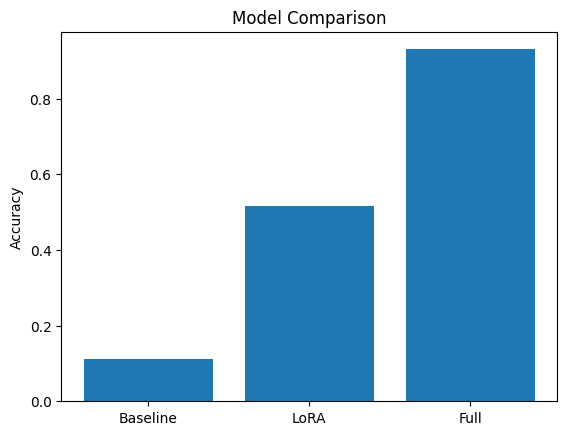

In [9]:
import matplotlib.pyplot as plt

models = ["Baseline", "LoRA", "Full"]
accuracy = [baseline_acc, lora_acc, full_acc]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

In [11]:
plt.savefig("results.png")

<Figure size 640x480 with 0 Axes>